In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from  scipy.stats import norm, t
from math import sqrt
import seaborn as sns


In [97]:
df = pd.read_parquet('../data/processed/fide_players.parquet')
df.head(10)

,fideid,name,country,sex,title,w_title,o_title,rating,rapid_rating,blitz_rating,birthday,flag
0,537001345,A Arbhin Vanniarajan,IND,M,nt,nt,nt,1450,1500,1431,2018,a
1,10245154,"A B M Jobair, Hossain",BAN,M,nt,nt,nt,1715,1738,1748,1998,a
2,558074015,A Bala Phani Prabhanjan,IND,M,nt,nt,nt,1585,1553,1524,2012,a
3,12457558,A Bu Ba Co,VIE,M,nt,nt,nt,0,1638,0,2002,a
4,25121731,A C J John,IND,M,nt,nt,nt,1438,0,0,1987,i
5,577037626,A C Jayaraghavan,IND,M,nt,nt,nt,1406,1407,0,2012,a
6,35077023,A Chakravarthy,IND,M,nt,nt,nt,1491,0,0,1986,i
7,537070436,A Darshil,IND,M,nt,nt,nt,1489,1609,1542,2013,a
8,10207538,"A E M, Doshtagir",BAN,M,nt,nt,nt,1904,1902,1916,1974,i
9,532004656,"A F M Ehteshamul, Hoque (tuhin",BAN,M,nt,nt,nt,1859,1760,0,1977,a


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 776188 entries, 0 to 776187
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   fideid        776188 non-null  int64   
 1   name          776188 non-null  str     
 2   country       776188 non-null  category
 3   sex           776188 non-null  category
 4   title         776188 non-null  category
 5   w_title       776188 non-null  category
 6   o_title       776188 non-null  category
 7   rating        776188 non-null  int64   
 8   rapid_rating  776188 non-null  int64   
 9   blitz_rating  776188 non-null  int64   
 10  birthday      776188 non-null  Int64   
 11  flag          776188 non-null  category
dtypes: Int64(1), category(6), int64(4), str(1)
memory usage: 55.1 MB


## Distribucion de elo global

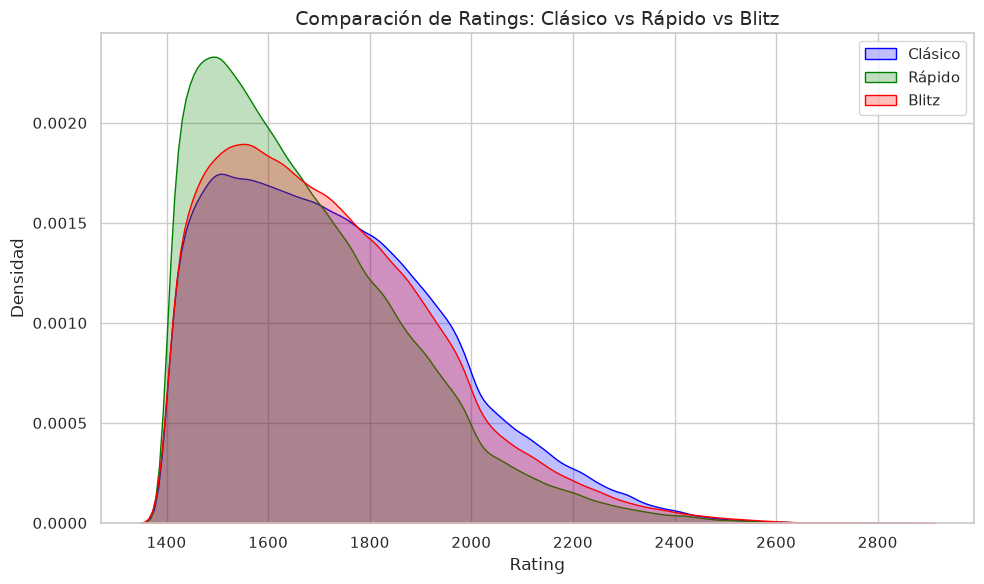

In [99]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


sns.kdeplot(df[df['rating'] > 0]['rating'], fill=True, color='blue', label='Clásico')
sns.kdeplot(df[df['rapid_rating'] > 0]['rapid_rating'], fill=True, color='green', label='Rápido')
sns.kdeplot(df[df['blitz_rating'] > 0]['blitz_rating'], fill=True, color='red', label='Blitz')

plt.title('Comparación de Ratings: Clásico vs Rápido vs Blitz', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

plt.legend()


plt.tight_layout()
plt.show()

## COnteo de jugadores globales

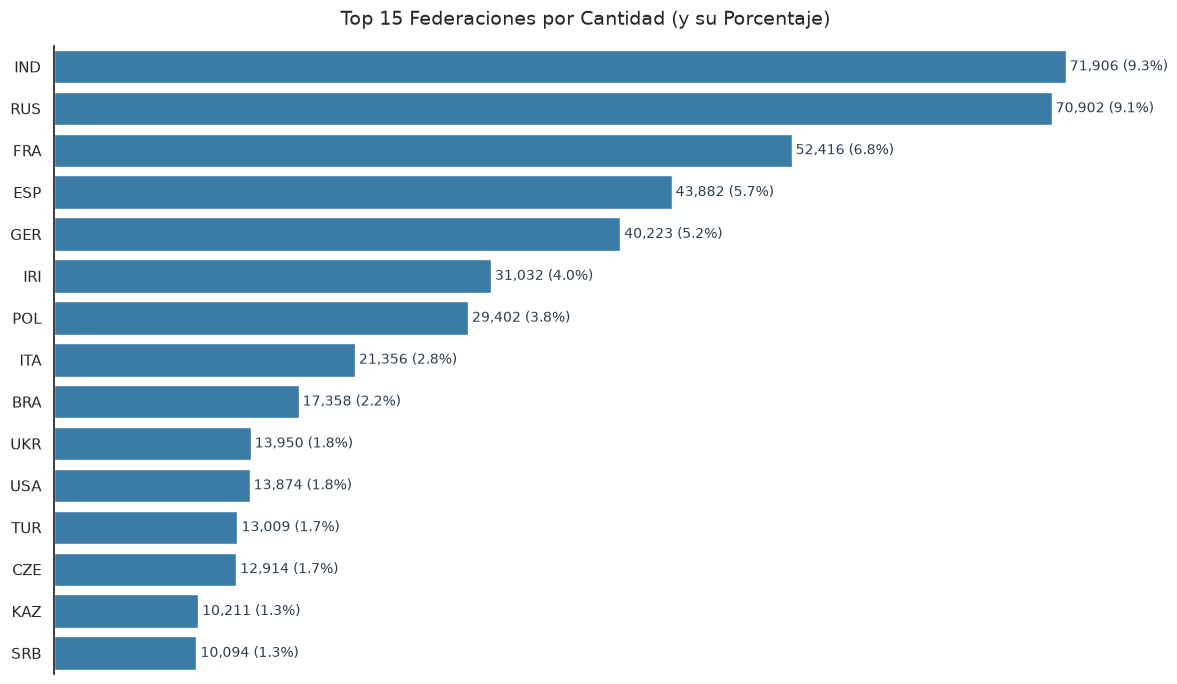

In [100]:

federaciones = df['country'].value_counts().rename_axis('federacion').reset_index(name='conteo')
federaciones['proporcion'] = federaciones['conteo'] / federaciones['conteo'].sum()
federaciones['porcentaje'] = np.round(federaciones['proporcion'], 4) 

top_15 = federaciones.head(15)


sns.set_theme(style="white") 


fig, ax = plt.subplots(figsize=(12, 7))


sns.barplot(
    data=top_15, 
    x='conteo', 
    y='federacion', 
    color='#2980b9',
    order=top_15['federacion'],
    ax=ax
)


ax.set_title('Top 15 Federaciones por Cantidad (y su Porcentaje)', fontsize=14, pad=15)
ax.set_ylabel('') 
ax.set_xlabel('') 
ax.xaxis.set_visible(False) 


sns.despine(bottom=True) 


for i, barra in enumerate(ax.patches):
    ancho = barra.get_width()
    pct = top_15['porcentaje'].iloc[i] 
    
    texto = f' {int(ancho):,} ({pct*100:.1f}%)' 
    
    ax.text(
        ancho,                           
        barra.get_y() + barra.get_height() / 2, 
        texto,
        ha='left', va='center', fontsize=10, color='#2c3e50'
    )

fig.tight_layout()
plt.show()


## Conteo de titulos globales

In [101]:
titulos = df['title'].value_counts().rename_axis('titulos').reset_index(name='conteo')
titulos['proporcion'] = titulos['conteo'] / titulos['conteo'].sum()
titulos['porcentaje'] = titulos['proporcion']


titulos

,titulos,conteo,proporcion,porcentaje
0,nt,751650,0.968387,0.968387
1,FM,9695,0.012491,0.012491
2,IM,4290,0.005527,0.005527
3,CM,3817,0.004918,0.004918
4,WFM,2213,0.002851,0.002851
5,GM,1899,0.002447,0.002447
6,WCM,1353,0.001743,0.001743
7,WIM,927,0.001194,0.001194
8,WGM,344,0.000443,0.000443


## Conteo de titulos por Federacion

In [102]:



titulos_FED = (
    pd.crosstab(index=df['country'], columns=df['title'])
    .assign(Total=lambda x: x.sum(axis=1))   
    .sort_values(by='Total', ascending=False) 
    .reset_index()                            
)

titulos_FED.columns.name = None \

nuevo_orden = [
    'country', 
    'GM', 'IM', 'FM', 'CM',      
    'WGM', 'WIM', 'WFM', 'WCM',  
    'nt',                       
    'Total'                      
]

titulos_FED = titulos_FED[nuevo_orden]

titulos_FED .head(10)

,country,GM,IM,FM,CM,WGM,WIM,WFM,WCM,nt,Total
0,IND,96,171,194,169,15,46,79,73,71063,71906
1,RUS,184,482,1239,100,39,96,401,38,68323,70902
2,FRA,60,133,299,96,9,19,36,6,51758,52416
3,ESP,60,151,470,219,3,15,57,10,42897,43882
4,GER,103,301,993,209,22,38,93,17,38447,40223
5,IRI,16,28,89,29,2,9,19,14,30826,31032
6,POL,56,122,242,131,13,30,66,39,28703,29402
7,ITA,18,52,194,38,1,4,18,4,21027,21356
8,BRA,15,34,122,64,0,8,14,17,17084,17358
9,UKR,85,188,206,28,19,30,37,4,13353,13950


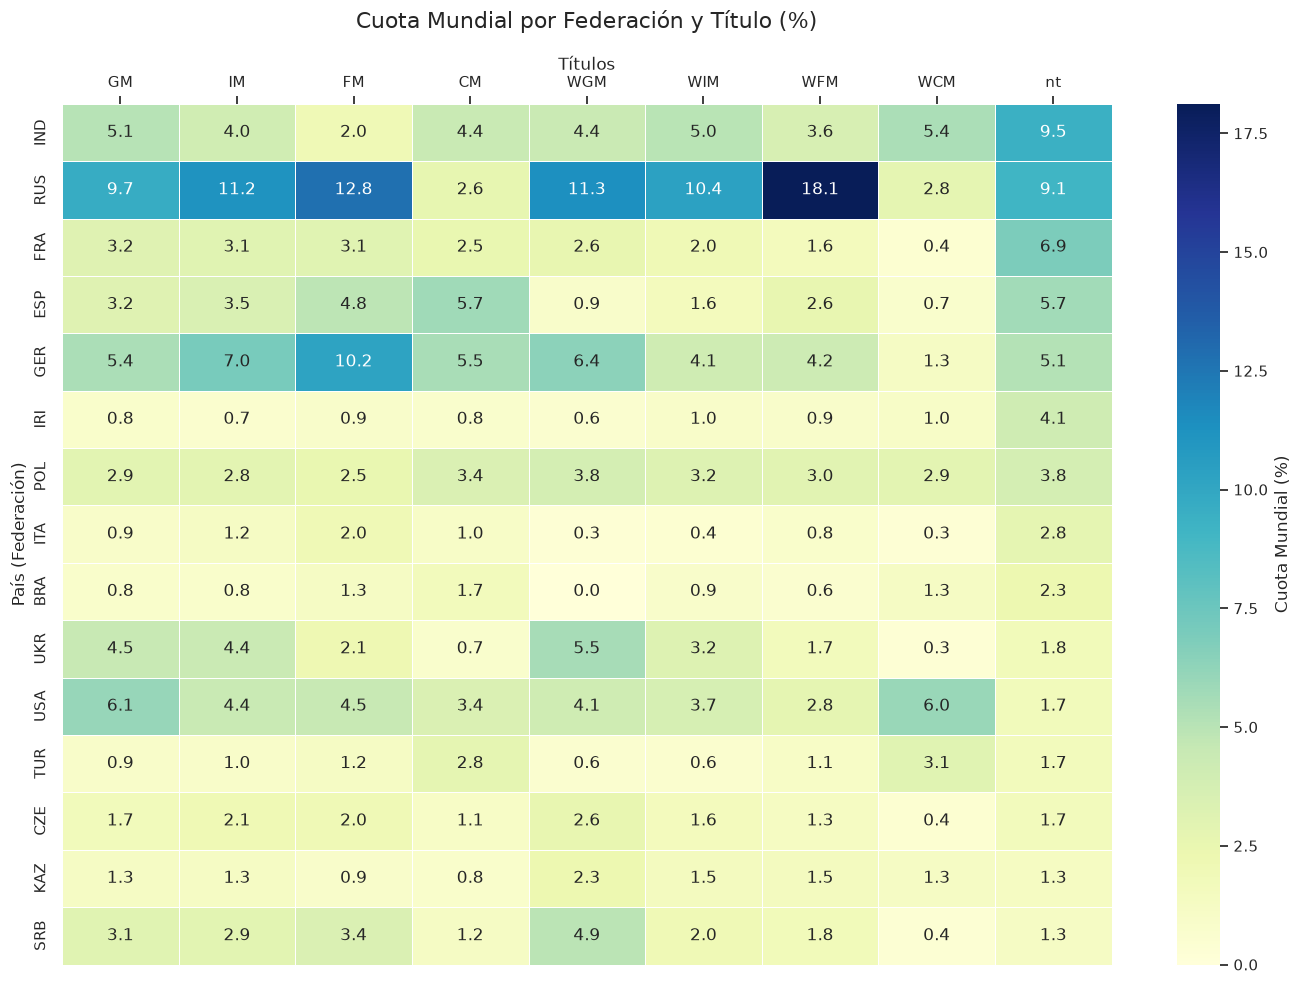

In [103]:

titulos_con_nt = ['GM', 'IM', 'FM', 'CM', 'WGM', 'WIM', 'WFM', 'WCM', 'nt']
df_plot_completo = titulos_FED.head(15)[['country'] + titulos_con_nt].set_index('country')
totales_mundiales = titulos_FED[titulos_con_nt].sum()
df_plot_cuota_mundial = (df_plot_completo.div(totales_mundiales, axis=1)) * 100

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(df_plot_cuota_mundial, cmap="YlGnBu", annot=True, fmt=".1f", 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cuota Mundial (%)'})

ax.set_title("Cuota Mundial por Federación y Título (%)", fontsize=16, pad=20)
ax.set_xlabel("Títulos", fontsize=12)
ax.set_ylabel("País (Federación)", fontsize=12)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
plt.tight_layout()
plt.show()



In [104]:
federaciones = df['country'].value_counts().rename_axis('federacion').reset_index(name='conteo')
federaciones['proporcion'] = federaciones['conteo'] / federaciones['conteo'].sum()
federaciones['porcentaje'] = np.round(federaciones['proporcion'],2)

federaciones.head(10)

,federacion,conteo,proporcion,porcentaje
0,IND,71906,0.092640,0.09
1,RUS,70902,0.091346,0.09
2,FRA,52416,0.067530,0.07
3,ESP,43882,0.056535,0.06
4,GER,40223,0.051821,0.05
5,IRI,31032,0.039980,0.04
6,POL,29402,0.037880,0.04
7,ITA,21356,0.027514,0.03
8,BRA,17358,0.022363,0.02
9,UKR,13950,0.017972,0.02
